# LAB ML-2: Regression (Linear + Polynomial on student grades) — SOLUTION

## PROBLEM STATEMENT (from `lab2_regression_handout.ipynb`)

> **Question.** Given a student's study habits, can we predict what grade
> they'll get on the final exam?
>
> In this lab you'll build a regression model that predicts a student's
> exam score on the **Danish 7-step scale** (`-3, 00, 02, 4, 7, 10, 12`).
> You'll start with one feature (study hours), then use all six. By the
> end you'll fill in your own habits and see the model's prediction for
> *you*.

The handout walks the student through five guided tasks (T1–T5) plus a
California-housing homework. Every "Concept → Intuition → Predict → Do →
Verify" rhythm and every markdown explainer below is preserved verbatim
from the handout. The TODO cells (T1, T2, T3, T4, T5) are the only cells
that change: each `raise NotImplementedError(...)` is replaced with a
working implementation, with `# KNOB:` blocks documenting every tunable
parameter the exam variants might want to flip.

The five tasks:

- **T1 — Simple linear regression** on `study_hours_per_week` only.
- **T2 — Multiple linear regression** on all six features.
- **T3 — Polynomial sweep + overfitting** on a toy 1-D dataset (default
  degrees `(1, 3, 12)` plus a second sweep `(2, 6, 18)` for variant 1).
- **T4 — Predict your own grade** by filling in `my_profile`.
- **T5 (bonus) — Gradient descent from scratch** on the T1 problem.

## MENTAL MODEL (L11 §2 analogies)

The lab uses the same picture L11 §2 (lecture lines 43–59) does — we are
**not** inventing new analogies, we are reusing the lecture's:

- **Linear regression = a single straight flight path on a 2-D chart of
  cities.** Each city sits at some longitude (x) and altitude (y); the
  flight path is the line. You can't pass over every city exactly, so
  you compromise on the route that *on average* misses by the least
  (L11 §2, lecture line 43).
- **A residual is how far each city sits above or below the flight
  path.** Positive = the city is above the line ($y_i > \hat y_i$);
  negative = below. The sign matters — the "distance" picture is only
  correct after squaring (L11 §2, lecture line 45).
- **OLS = the flight path that minimises the sum of *squared*
  city-offsets.** Squaring matters: a city 10 km off counts not twice
  but **four times** as much as one 5 km off. OLS therefore weights
  large misses heavily and settles on the line that splits the
  difference between every pull the data exerts (L11 §2, lecture line
  47; L11 §3.3 "OLS-as-squared-penalty").
- **$R^2$ = the share of the data's spread that the flight path
  absorbs.** Total spread = SST; the leftover after fitting = SSE; what
  the line captured = SSR = SST − SSE. Then $R^2 = $ SSR / SST = 1 −
  SSE / SST (L11 §2 "shotgun-spread", §3.5–3.6).
- **Polynomial degree** is not an L11 §2 analogy — L11 forward-references
  polynomial regression as "a route to flexibility" in §3.13. The key
  insight is that even with `PolynomialFeatures(degree=d)`, the model
  is still **linear in its parameters**, so `LinearRegression` works
  unchanged. Higher degree = more flexibility = more risk of memorising
  noise (overfitting).
- **Gradient descent = rolling a marble down a bowl-shaped loss
  surface.** Each step nudges the parameters in the direction the bowl
  is steepest down. This analogy is the **lab's**, not L11's: L11 §1
  (lecture line 27) explicitly punts gradient descent to "ML Lab 2" —
  the iterative-optimisation perspective belongs *here*. L11 treats
  `lm()`/`LinearRegression()` as a closed-form black box only.

## SST / SSE / SSR — the single most important diagram in L11

L11 §3.5 calls the sum-of-squares decomposition "the single most
important diagram in the lecture" (lecture line 186). Three pieces:

- **SST = $\sum_i (y_i - \bar y)^2$** — Total Sum of Squares. The
  variability you face *before* any model, i.e. how badly the
  "predict-the-mean" baseline misses. Every model must beat SST.
- **SSE = $\sum_i (y_i - \hat y_i)^2$** — Error Sum of Squares. What's
  left *after* the model: the squared residuals OLS minimises.
- **SSR = SST − SSE = $\sum_i (\hat y_i - \bar y)^2$** — Regression
  Sum of Squares. What the model managed to *explain*.

Then $\boxed{R^2 = \dfrac{\text{SSR}}{\text{SST}} = 1 - \dfrac{\text{SSE}}{\text{SST}}}$.

The lab also writes $R^2$ as $1 - \text{MSE}_\text{model}/\text{MSE}_\text{lazy}$
in cell 13 — same quantity, since $\text{MSE} = \text{SSE}/n$ and
$\text{MSE}_\text{lazy} = \text{SST}/n$ (the $n$'s cancel). Memorise the
L11 form; the lab's MSE form is just the sklearn-friendly renaming.

## Adjusted $R^2$ — the right metric for comparing models with different $p$

L11 §3.7 (lecture lines 220–241) warns: $R^2$ *never decreases* when you
add a predictor, even a useless one. Comparing raw $R^2$ across models
with different numbers of predictors is therefore naive. Use:

$$R^2_\text{adj} = 1 - \dfrac{n-1}{n-p-1}\,(1 - R^2),$$

where $n$ is the sample size and $p$ is the number of predictors
(intercept not counted). The multiplier $(n-1)/(n-p-1)$ swells above 1
as $p$ grows, so a useless extra predictor barely moves $R^2$ but
*lowers* $R^2_\text{adj}$. The lab compares T1 (p = 1) and T2 (p = 6) on
the held-out *test* set, which is a different (and equally valid)
defence against the same problem — a useless predictor will fail to
generalise and so will hurt test-set $R^2$ on its own. Both
approaches are exam-relevant. The lab's T2 sanity check prints the
adjusted-$R^2$ for both T1 and T2 alongside the raw values so you can
see the penalty in action.

## REFERENCES

- **L11 Regression** — `study/lectures/L11-Regression.md`
  (flight-path analogy §2; OLS / residual / SST-SSE-SSR §3.3–§3.6;
  adjusted $R^2$ §3.7; dummy / interaction / multicollinearity
  §3.10–§3.12 — **not** covered in this lab; polynomial regression
  forward-reference §3.13).
  Important: L11 itself does **not** cover gradient descent, MSE/RMSE
  by name, learning rate, or epochs. Those are this lab's contribution.
- **L10 Intro to ML** — `study/lectures/L10-Intro-to-ML.md`
  (train/test split, overfitting, MAE/MSE/R² as evaluation metrics).
- **Glossary** — `study/_shared/glossary.md`: *linear regression*,
  *polynomial regression*, *ordinary least squares*, *overfitting*,
  *train/test split*, *R²*, *MSE*, *MAE*, *gradient descent*,
  *learning rate*.

## HOW TO ADAPT THIS FOR DIFFERENT QUESTION VARIANTS

See `study/_exam/MLLab2-Regression/variants.md` for the full curated
variant bank. Quick guide:

1. **Polynomial-degree sweep (variant 1):** the notebook ships with
   *two* sweeps so one execution covers the variant's "six rows"
   requirement: `POLY_DEGREES_SWEEP` (default `(1, 3, 12)`) and
   `POLY_DEGREES_SWEEP_2` (default `(2, 6, 18)`). Change either tuple
   to any length; the verify cell now resizes its subplot grid
   automatically. The toy dataset itself is governed by
   `TOY_RANDOM_SEED`, `TOY_N_TRAIN`, `TOY_NOISE_STD`.
2. **Drop a feature from the multiple regression (variant 2):** change
   the KNOB `T2_FEATURE_SUBSET` in the T2 cell. Allowed values:
   - `"all"` — default; uses every column in `FEATURE_COLS`.
   - `"drop_study_hours"` — drops `study_hours_per_week`.
   - any explicit Python list of column names (subset of `FEATURE_COLS`).
3. **Predict a new student row (variant 3):** rewrite the `my_profile`
   dict in the T4 cell with the variant's values. The dict's KNOB
   block documents the allowed range for each entry.
4. **Bonus — gradient descent tuning (variant 4):** change
   `GD_LEARNING_RATE` (small → slow convergence; large → instability)
   and/or `GD_N_EPOCHS` in the T5 prep cell.
5. **Bonus — split ratio (variant 5):** change `TEST_SPLIT_RATIO` at
   the top of T1; T2 reuses the same constant so the comparison stays
   apples-to-apples.

Every KNOB ships with its own `# KNOB:` block explaining default,
allowed range, the effect, and which variant the knob is for.

## OUTPUTS WHEN RUN

Running every cell top-to-bottom produces:

- T1 sanity check: `MAE ≈ 1.54, MSE ≈ 3.5, R² ≈ 0.32` (1-feature model
  beats the lazy baseline by ~0.3 grade points).
- T2 sanity check: `MAE ≈ 0.85, MSE ≈ 1.20, R² ≈ 0.77` (6-feature
  model adds ~0.45 R² over T1); adjusted-$R^2$ also printed.
- T3 sanity check: **two** sweeps printed. Default sweep `(1, 3, 12)`:
  degree 1 underfits (~0.3 R²), degree 3 fits well (~0.87 R²),
  degree 12 overfits dramatically (train R² ≈ 1.0, test R² collapses
  below 0.6). Second sweep `(2, 6, 18)`: degree 2 underfits, degree 6
  fits well, degree 18 overfits even more catastrophically. Six rows
  in the combined table — variant 1's requested output.
- T4 sample prediction for the default `my_profile`: `final_score ≈ 9.70`,
  snapped Danish grade `10`.
- T5 sanity check: `|Δw| < 0.05, |Δb| < 0.05` versus sklearn's
  closed-form answer; loss curve drops monotonically.
- Several matplotlib figures (line fits, residuals, coefficient bar
  charts, the polynomial-degree triptychs for both sweeps, the
  gradient-descent loss curve, and a feature-contribution chart for
  the student profile).

## ENTRY POINT: yes

A `.ipynb` is always an entry point. The Verifier executes the whole
notebook via `py -3.12 -m jupyter nbconvert --to notebook --execute
--inplace=false`; every cell must succeed without raising.


# Lab 2 — Regression: Predict Your Own Grade

**Question.** Given a student's study habits, can we predict what grade
they'll get on the final exam?

In this lab you'll build a regression model that predicts a student's
exam score on the **Danish 7-step scale** (`-3, 00, 02, 4, 7, 10, 12`).
You'll start with one feature (study hours), then use all six. By the
end you'll fill in your own habits and see the model's prediction for
*you*.

> Every new idea — residual, MSE, R², coefficient, overfitting,
> gradient descent — is explained inside this notebook from first
> principles, right before you're asked to use it. If your lecturer
> hasn't covered something yet, keep going: the lab is self-contained.


## How to use this lab

Each section follows the same rhythm so you don't have to re-learn how to
read the lab every few cells:

1. **Concept** — a short plain-English explainer of the new idea.
2. **Intuition** — a pre-filled code cell that draws a picture. *Just run it.*
3. **Predict** — one line where you commit to a guess before you write code.
4. **Do** — a `# TODO` cell where you write a few lines yourself. The task
   prompt above it tells you *what* to build and which variable names to
   use. If you're stuck, open the collapsible **Hint 1 → Hint 2 → Hint 3**
   sections one at a time — each reveals more detail, ending with a
   near-solution skeleton.
5. **Verify** — a pre-filled sanity-check cell that prints your numbers
   alongside the expected values. If they match, you got it right.

**Try to write the code yourself before opening a hint.** Hints are there
so you can get unstuck without asking, not so you can skip the thinking.

### Local setup

```bash
conda create -n ai101-ml python=3.12 -y
conda activate ai101-ml
python -m pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```

Or with `uv`:

```bash
uv venv --python 3.12 .venv
source .venv/bin/activate
uv pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```


In [1]:
# Imports and plot theme — run once, then forget about this cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

COLORS = {
    'blue':   '#3563E9',
    'teal':   '#0F9D8A',
    'orange': '#F28E2B',
    'red':    '#D64545',
    'gold':   '#B88700',
    'slate':  '#5F6C7B',
    'navy':   '#264653',
}

print('Setup complete. Ready to predict some grades.')


Setup complete. Ready to predict some grades.


## 0. Warm-up — sklearn in 4 lines

Before we touch any real data, let's see the whole regression workflow on
a tiny clean example. You'll notice: to fit a straight line to data, you
only need **four lines of sklearn**.

The idea of linear regression is to find a line:

$$\hat{y} = w \cdot x + b$$

- `x` is the input feature (e.g. study hours).
- `\hat{y}` ("y-hat") is the predicted output (e.g. grade).
- `w` (*weight*, a.k.a. *slope*) tells you how much `\hat{y}` changes when
  `x` goes up by 1.
- `b` (*bias*, a.k.a. *intercept*) is where the line crosses the y-axis —
  the prediction when `x = 0`.

Below we generate 80 fake data points from a true line `y = 1.8 x + 4`
plus random noise, then ask sklearn to recover `w` and `b` from the noisy
data alone.


True line    :  y = 1.80 x + 4.00
Learned line :  y = 1.79 x + 4.07
R^2 on the training points: 0.960


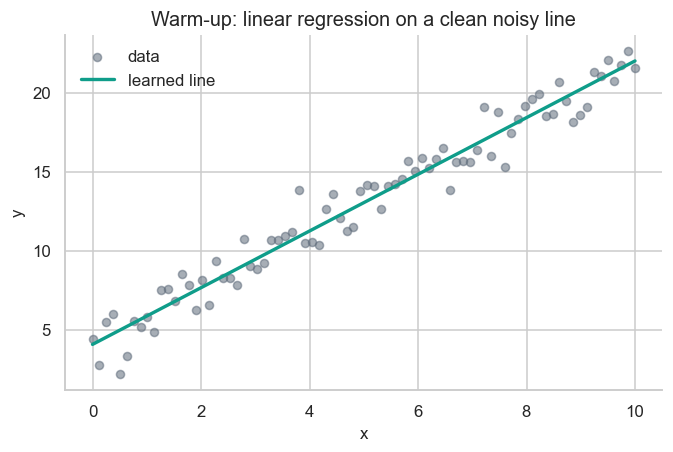

In [2]:
# --- Intuition demo (just run it) ---

rng = np.random.default_rng(42)
x_demo = np.linspace(0, 10, 80).reshape(-1, 1)
true_w, true_b = 1.8, 4.0
y_demo = true_b + true_w * x_demo.flatten() + rng.normal(0, 1.4, size=80)

# The four lines of sklearn:
demo_model = LinearRegression()           # 1. create the model
demo_model.fit(x_demo, y_demo)            # 2. learn w and b from data
y_hat = demo_model.predict(x_demo)        # 3. predict
r2 = r2_score(y_demo, y_hat)              # 4. score

print(f'True line    :  y = {true_w:.2f} x + {true_b:.2f}')
print(f'Learned line :  y = {demo_model.coef_[0]:.2f} x + {demo_model.intercept_:.2f}')
print(f'R^2 on the training points: {r2:.3f}')

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.scatter(x_demo, y_demo, color=COLORS['slate'], alpha=0.55, s=28, label='data')
ax.plot(x_demo, y_hat, color=COLORS['teal'], lw=2.2, label='learned line')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Warm-up: linear regression on a clean noisy line')
ax.legend()
plt.show()


**What to notice.** The learned `w` and `b` are very close to the true
`1.80` and `4.00` even though we only gave the model noisy points — no
straight line at all. That's what regression does: it finds the line
that best explains the data.


## 1. The student grade dataset

We'll work with a synthetic dataset of **360 students**, each described
by six study habits, plus their final exam **score** (a number between
roughly `-3` and `12`) and their **grade** on the Danish 7-step scale
obtained by snapping the score to the nearest allowed value in
`{-3, 00, 02, 4, 7, 10, 12}`.

| Column | Meaning |
|---|---|
| `study_hours_per_week` | Average hours/week spent studying the course |
| `attendance_rate_pct` | Share of lectures attended (%) |
| `prior_math_grade` | Danish-scale grade from the previous math course |
| `sleep_hours` | Average nightly sleep (hours) |
| `exercises_completed` | Weekly exercises completed (0–10) |
| `prior_programming_years` | Years of prior programming experience |
| `final_score` | Exam score (continuous, **regression target**) |
| `final_grade` | `final_score` snapped to the Danish scale |

We target the continuous `final_score` so we can use regression; at the
very end we snap the prediction back to a valid Danish grade for the big
reveal.


In [3]:
# --- Build the dataset. Just run this cell. ---

DANISH_SCALE = np.array([-3, 0, 2, 4, 7, 10, 12], dtype=float)

def snap_to_danish(score):
    """Round each score to the nearest Danish grade in {-3, 0, 2, 4, 7, 10, 12}."""
    score = np.asarray(score, dtype=float)
    return DANISH_SCALE[np.argmin(np.abs(score[..., None] - DANISH_SCALE), axis=-1)]

def make_student_grade_data(n_students=360, random_state=42):
    rng = np.random.default_rng(random_state)
    study        = np.clip(rng.normal(8.0,  3.5, n_students), 0.5, 20.0)
    attendance   = np.clip(rng.normal(82.0, 12.0, n_students), 40.0, 100.0)
    prior_math   = rng.choice(DANISH_SCALE, size=n_students,
                              p=[0.05, 0.10, 0.18, 0.25, 0.22, 0.15, 0.05])
    sleep        = np.clip(rng.normal(7.0, 1.2, n_students), 3.0, 10.0)
    exercises    = rng.integers(0, 11, size=n_students).astype(int)
    prog_years   = np.clip(rng.exponential(1.2, n_students), 0.0, 6.0)

    # Hidden generative formula — don't peek if you want the exercise to be honest!
    score = (
        -3.0
        + 0.45 * study
        + 0.025 * attendance
        + 0.35 * prior_math
        - 0.30 * (sleep - 7.2) ** 2
        + 0.18 * exercises
        + 0.30 * prog_years
        + rng.normal(0.0, 1.0, n_students)
    )
    score = np.clip(score, -3.0, 12.0)

    df = pd.DataFrame({
        'study_hours_per_week':     np.round(study, 1),
        'attendance_rate_pct':      np.round(attendance, 1),
        'prior_math_grade':         prior_math.astype(int),
        'sleep_hours':              np.round(sleep, 1),
        'exercises_completed':      exercises,
        'prior_programming_years':  np.round(prog_years, 1),
        'final_score':              np.round(score, 2),
        'final_grade':              snap_to_danish(score).astype(int),
    })
    return df

FEATURE_COLS = [
    'study_hours_per_week',
    'attendance_rate_pct',
    'prior_math_grade',
    'sleep_hours',
    'exercises_completed',
    'prior_programming_years',
]

df = make_student_grade_data()
print(f'Dataset shape: {df.shape}')
df.head()


# ---------------------------------------------------------------------------
# Global KNOBs read by the rest of the notebook.
# ---------------------------------------------------------------------------

# KNOB: TEST_SPLIT_RATIO (default=0.2, range=(0.1, 0.5))
#   What it does: fraction of the 360-student dataset reserved for the
#     test split in T1, T2, and the T2 feature-drop variant.
#   Effect: smaller test fraction = more training data = lower variance
#     in coefficients but a noisier test-R^2 estimate. The sanity-check
#     tolerances assume 0.2.
#   Exam variants: variant 5 sets this to 0.5 to halve the training set
#     and watch R^2 degrade. Keep at 0.2 for variants 1-3.
TEST_SPLIT_RATIO = 0.2

# KNOB: SPLIT_RANDOM_STATE (default=42, allowed=any int)
#   What it does: seed handed to sklearn's train_test_split so the same
#     students go into train and test across re-runs.
#   Effect: changing the seed reshuffles the split — useful as a quick
#     sanity check that results are not seed-cherry-picked.
#   Exam variants: keep at 42 for every variant unless the variant text
#     explicitly says "with a different seed".
SPLIT_RANDOM_STATE = 42

# KNOB: POLY_DEGREES_SWEEP (default=(1, 3, 12), allowed=tuple of positive ints,
#                           any length >= 1)
#   What it does: the polynomial degrees evaluated in T3's *first* toy
#     overfitting sweep.
#   Effect: low degrees underfit, mid degrees fit well, high degrees
#     overfit. The verify cell (cell 32) reads len(POLY_DEGREES_SWEEP)
#     at runtime and draws a 1 x len() subplot grid — no manual
#     bookkeeping needed when you change the tuple length.
#   Exam variants: variant 1 keeps this at (1, 3, 12) for the
#     underfit -> goodfit -> overfit baseline; the second sweep
#     (POLY_DEGREES_SWEEP_2 below) does the (2, 6, 18) replay, so
#     a single notebook execution prints all six (degree, train, test)
#     rows.
POLY_DEGREES_SWEEP = (1, 3, 12)

# KNOB: POLY_DEGREES_SWEEP_2 (default=(2, 6, 18), allowed=tuple of positive ints,
#                              any length >= 1)
#   What it does: a *second* polynomial sweep run on the same toy
#     dataset right after the first one. Lets variant 1's "report six
#     (degree, train_R^2, test_R^2) rows" answer come out of a single
#     notebook execution.
#   Effect: identical role to POLY_DEGREES_SWEEP — same fit/score
#     loop, same verify plot, just at different degrees. Set to an
#     empty tuple () if you want to skip the second sweep.
#   Exam variants: variant 1 reads this as (2, 6, 18) to confirm the
#     underfit -> goodfit -> overfit progression at a different scale.
POLY_DEGREES_SWEEP_2 = (2, 6, 18)

# KNOB: TOY_RANDOM_SEED (default=7, allowed=any int)
#   What it does: seed for the toy 1-D dataset used by T3. Controls
#     both training-point noise and test-point noise.
#   Effect: different seeds reshuffle the noise sprinkled around the
#     true wiggle curve. R^2 numbers will shift slightly but the
#     underfit -> goodfit -> overfit *pattern* across degrees is robust
#     to the seed.
#   Exam variants: variant 1 typically keeps this at 7 so the
#     comparison between the two sweeps is apples-to-apples.
TOY_RANDOM_SEED = 7

# KNOB: TOY_N_TRAIN (default=14, allowed=int in roughly 8..200)
#   What it does: number of training points in T3's toy dataset.
#     Few training points + a flexible model is the recipe that makes
#     overfitting dramatic.
#   Effect: more train points -> harder to overfit at high degree, so
#     the train/test gap at degree 12 shrinks. With ~50 points even
#     degree 18 fits okay.
#   Exam variants: variant 1 keeps this at 14 — raising it would
#     suppress the overfitting payoff. The test set is fixed at 40
#     points regardless.
TOY_N_TRAIN = 14

# KNOB: TOY_NOISE_STD (default=0.45, allowed=float in 0.0..2.0)
#   What it does: standard deviation of the Gaussian noise added to
#     both the toy training and toy test points.
#   Effect: low noise -> the true wiggle is easy to see and even
#     simple polynomials do well; high noise -> all degrees do worse
#     on test, and overfit-versus-fit signals get harder to separate.
#   Exam variants: variant 1 keeps this at 0.45 so the pattern is
#     dramatic but not pathological.
TOY_NOISE_STD = 0.45

# KNOB: T2_FEATURE_SUBSET (default="all",
#                          allowed={"all", "drop_study_hours",
#                                   list of column names from FEATURE_COLS})
#   What it does: chooses which columns of the dataset feed the T2
#     multiple regression.
#   Effect:
#     - "all" -> all six features (the default; matches the handout
#       sanity check).
#     - "drop_study_hours" -> the five features other than
#       study_hours_per_week. R^2 drops by ~0.2-0.3 because the strongest
#       single signal is removed.
#     - explicit list -> any subset of FEATURE_COLS; T2 still runs but
#       the sanity check's expected values will not match.
#   Exam variants: variant 2 uses "drop_study_hours".
T2_FEATURE_SUBSET = "all"


Dataset shape: (360, 8)


Summary statistics:


,study_hours_per_week,attendance_rate_pct,prior_math_grade,sleep_hours,exercises_completed,prior_programming_years,final_score,final_grade
count,360.00,360.00,360.00,360.00,360.00,360.00,360.00,360.00
mean,7.97,80.77,4.90,7.01,5.01,1.25,5.15,5.14
std,3.29,11.54,3.87,1.25,3.07,1.29,2.29,2.44
min,0.50,46.40,-3.00,3.60,0.00,0.00,-1.16,0.00
25%,5.70,72.60,2.00,6.20,2.00,0.40,3.56,4.00
50%,7.95,81.00,4.00,7.00,5.00,0.90,5.29,4.00
75%,10.10,88.78,7.00,7.80,8.00,1.70,6.72,7.00
max,18.20,100.00,12.00,10.00,10.00,6.00,12.00,12.00


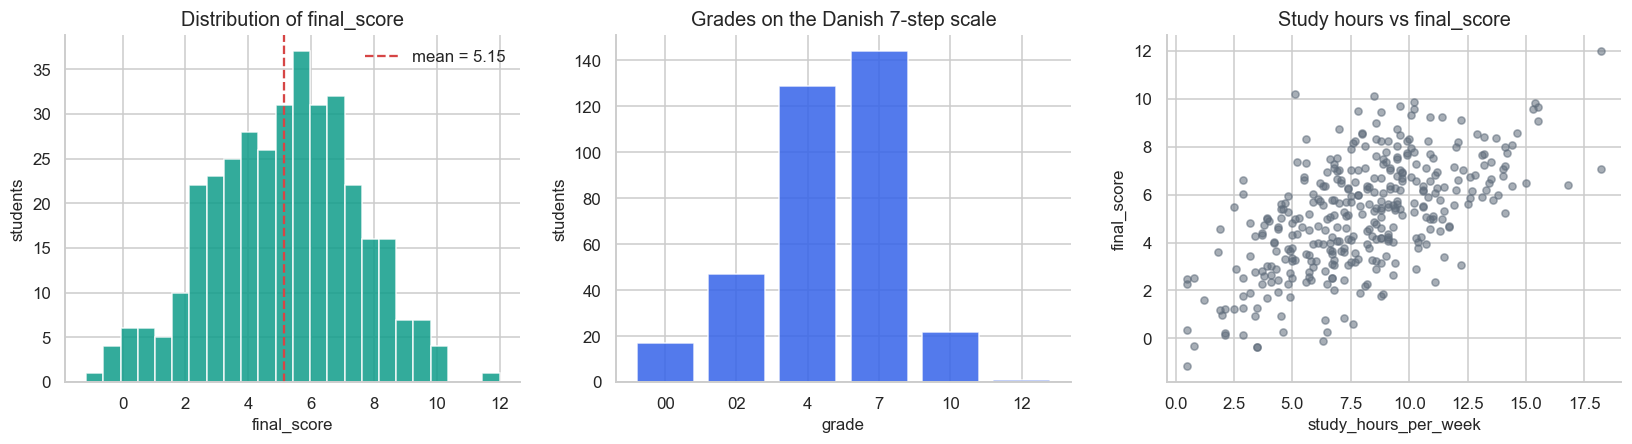

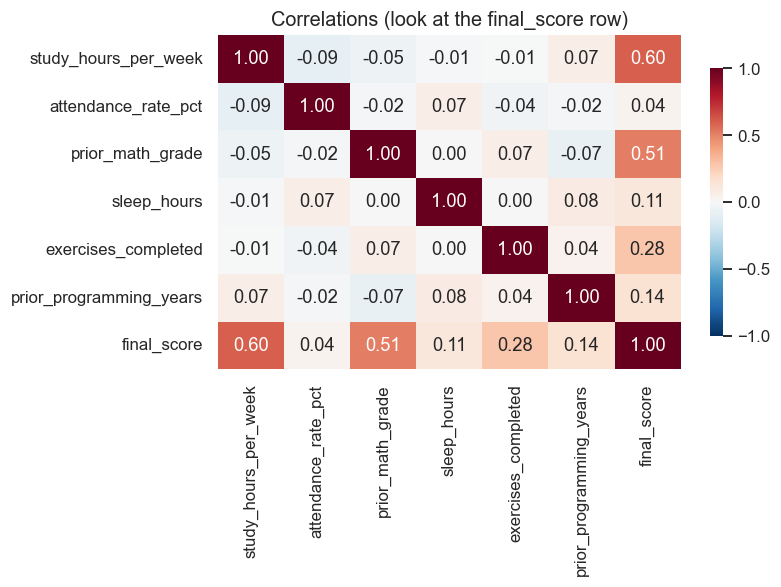

In [4]:
# --- Quick look at the data: summary, distribution, correlations. ---

print('Summary statistics:')
display(df.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(df['final_score'], bins=24, color=COLORS['teal'], alpha=0.85, edgecolor='white')
axes[0].axvline(df['final_score'].mean(), color=COLORS['red'], ls='--',
                label=f"mean = {df['final_score'].mean():.2f}")
axes[0].set_title('Distribution of final_score')
axes[0].set_xlabel('final_score'); axes[0].set_ylabel('students')
axes[0].legend()

grade_counts = df['final_grade'].value_counts().sort_index()
grade_labels = ['00' if g == 0 else ('02' if g == 2 else str(g)) for g in grade_counts.index]
axes[1].bar(grade_labels, grade_counts.values, color=COLORS['blue'], alpha=0.85)
axes[1].set_title('Grades on the Danish 7-step scale')
axes[1].set_xlabel('grade'); axes[1].set_ylabel('students')

axes[2].scatter(df['study_hours_per_week'], df['final_score'],
                s=22, alpha=0.55, color=COLORS['slate'])
axes[2].set_title('Study hours vs final_score')
axes[2].set_xlabel('study_hours_per_week'); axes[2].set_ylabel('final_score')

plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
corr = df[FEATURE_COLS + ['final_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlations (look at the final_score row)')
plt.tight_layout(); plt.show()


**What to notice.**

- The grade distribution is centred around **4** and **7** — realistic
  for an intro course. Very few `-3`s or `12`s.
- In the correlation heatmap, the strongest positive bars in the
  `final_score` row are **`study_hours_per_week`** and
  **`prior_math_grade`**. Those will likely be the most useful features.
- `sleep_hours` shows almost no linear correlation because the
  relationship is *quadratic* — both too little and too much sleep hurt.
  A plain linear model can't capture this; it's a known limitation, not
  a bug.


## 2. The lazy baseline — always predict the mean

Before we build anything clever, let's see what *no model* looks like.
The **lazy predictor** always predicts the same number: the average
score across all students. It ignores every feature. If our real model
can't beat this, we haven't learned anything.

The natural error metric for regression is **MAE** (*mean absolute
error*): the average of `|y_true − y_pred|` across the dataset. It's in
the same units as the target, so an MAE of `2.0` means "off by two
grade points on average."


Lazy predictor always guesses: 5.15
Lazy predictor MAE (whole dataset): 1.85  <- the bar to beat


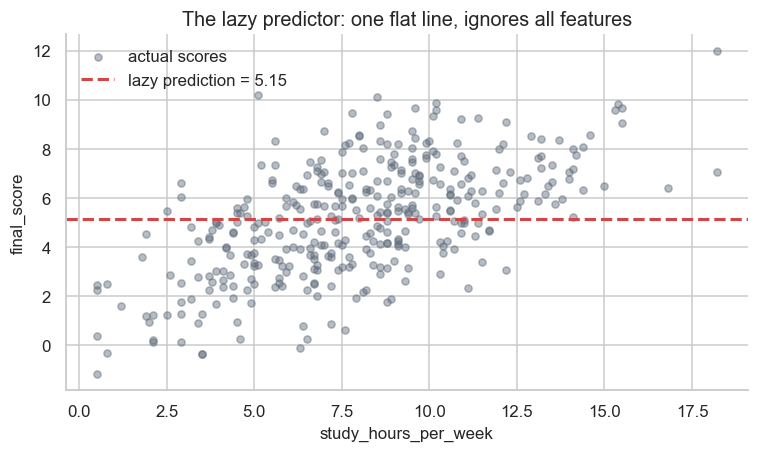

In [5]:
# --- The lazy predictor and its error. ---

# The classroom-friendly picture: predict the overall mean for every
# row. This is the *full-dataset* lazy baseline, which doubles as L11's
# SST/n proxy (predict-the-mean is the SST baseline; lecture lines
# 163–167).
lazy_prediction = df['final_score'].mean()
lazy_mae = mean_absolute_error(df['final_score'], [lazy_prediction] * len(df))

print(f'Lazy predictor always guesses: {lazy_prediction:.2f}')
print(f'Lazy predictor MAE (whole dataset): {lazy_mae:.2f}  <- the bar to beat')

# For the honest T1/T2 comparisons we need a lazy baseline computed on
# the **test** split (predicting y_train.mean() for every y_test student).
# The split happens in cell 17; we store the test-set lazy MAE there.

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(df['study_hours_per_week'], df['final_score'],
           s=22, alpha=0.45, color=COLORS['slate'], label='actual scores')
ax.axhline(lazy_prediction, color=COLORS['red'], ls='--', lw=2,
           label=f'lazy prediction = {lazy_prediction:.2f}')
ax.set_xlabel('study_hours_per_week'); ax.set_ylabel('final_score')
ax.set_title('The lazy predictor: one flat line, ignores all features')
ax.legend()
plt.show()


## 3. T1 — Your first regression model

### The concept

A **linear regression model** with one feature looks like:

$$\hat{y} = w \cdot x + b$$

- `\hat{y}` is the predicted `final_score`.
- `x` is the feature we're using. We'll pick `study_hours_per_week`.
- `w` and `b` are the two knobs the model learns from data.

For each student the **residual** is the vertical distance between the
actual score and the predicted line:

$$\text{residual}_i = y_i - \hat{y}_i$$

Positive residuals mean the model *under-*predicted that student;
negative residuals mean it *over-*predicted.

To measure how good the line is, we summarise the residuals with three numbers:

- **MAE** (mean absolute error): average of `|residual|`. Same units as `y`.
- **MSE** (mean squared error): average of `residual²`. Punishes big misses
  extra hard because of the squaring.
- **R²** (coefficient of determination): a rescaled score where `0` means
  "no better than the lazy predictor" and `1` means "perfect." Formally
  `R² = 1 − MSE_model / MSE_lazy`. Higher is better; can go negative if
  the model is *worse* than guessing the mean.

### Why train/test?

If we let the model peek at every point and then grade it on the same
points, we're cheating — just like a student who studies a specific exam
paper. Instead we split the data: **80%** for the model to learn from,
**20%** that the model never sees until we're ready to grade it.


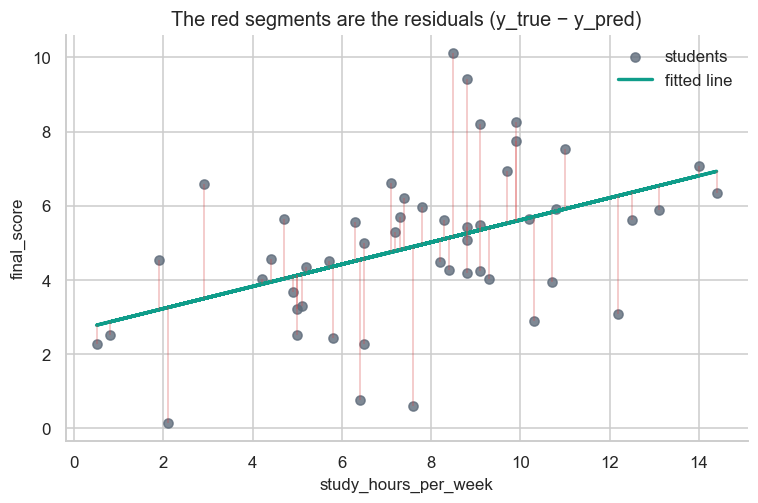

Demo line: y = 0.30 * study_hours + 2.63


In [6]:
# --- Intuition: a line through the data, with residuals drawn in. ---

small = df[['study_hours_per_week', 'final_score']].sample(50, random_state=0)
xs = small['study_hours_per_week'].values.reshape(-1, 1)
ys = small['final_score'].values

demo_model = LinearRegression().fit(xs, ys)
y_line = demo_model.predict(xs)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(xs, ys, s=36, alpha=0.8, color=COLORS['slate'], label='students')
ax.plot(xs, y_line, color=COLORS['teal'], lw=2.2, label='fitted line')
for xi, yi, yhi in zip(xs.flatten(), ys, y_line):
    ax.vlines(xi, min(yi, yhi), max(yi, yhi),
              color=COLORS['red'], alpha=0.35, lw=1)
ax.set_xlabel('study_hours_per_week'); ax.set_ylabel('final_score')
ax.set_title('The red segments are the residuals (y_true − y_pred)')
ax.legend()
plt.show()

print(f'Demo line: y = {demo_model.coef_[0]:.2f} * study_hours + {demo_model.intercept_:.2f}')


### Predict before you fit

Before running the code cell below, commit to a guess:

- Do you expect `R²` to be around `0.05`, `0.3`, or `0.7` when we use
  **only** `study_hours_per_week`?
- By how many grade points do you think the model will beat the lazy
  predictor's MAE of about `1.85`?


### T1 — Build your first regression model

Using the single feature `study_hours_per_week`, fit a linear regression to predict `final_score`. Then score it on the test set using MAE, MSE, and R².

**Required variables after your code runs:** `X1, y, X1_train, X1_test, y_train, y_test, model_t1, y_pred_t1, mae_t1, mse_t1, r2_t1`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

You'll do five things, in order:

1. Build `X1` (the 2-D feature matrix — one column, every student a row) and `y` (the target vector).
2. Split into train and test so the model gets graded on data it didn't see.
3. Create an empty `LinearRegression` model.
4. Fit it on the training split; predict on the test split.
5. Compute MAE, MSE, and R² by comparing predictions to the true test targets.

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

The sklearn functions you already imported:

- `train_test_split(X, y, test_size=0.2, random_state=42)` returns four things in this order: `X_train, X_test, y_train, y_test`.
- `LinearRegression()` creates the model. Then `.fit(X_train, y_train)` learns `w` and `b`, and `.predict(X_test)` returns predictions.
- `mean_absolute_error`, `mean_squared_error`, `r2_score` all take `(y_true, y_pred)` in that order.

Two traps to avoid:
- `X` needs to be **2-D** even with one feature. `df[['col']].values` gives `(n, 1)`; `df['col'].values` gives `(n,)` — use the double brackets.
- Always set `random_state=42` so your numbers match the sanity check.

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
X1 = df[['study_hours_per_week']].values
y  = df['final_score'].values

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42,
)

model_t1 = LinearRegression()
model_t1.fit(X1_train, y_train)

y_pred_t1 = model_t1.predict(X1_test)
mae_t1 = mean_absolute_error(y_test, y_pred_t1)
mse_t1 = mean_squared_error(y_test, y_pred_t1)
r2_t1  = r2_score(y_test, y_pred_t1)
```

</details>


In [7]:
##############################################################
###          T1 -- Simple linear regression (SOLUTION)     ###
##############################################################
# Required variables:
#   X1, y, X1_train, X1_test, y_train, y_test,
#   model_t1, y_pred_t1, mae_t1, mse_t1, r2_t1
#
# Strategy: the five-step recipe from the markdown above. The only
# subtleties are (a) X must be 2-D for sklearn even with one feature
# (we use the double-bracket DataFrame idiom), and (b) reading the
# TEST_SPLIT_RATIO / SPLIT_RANDOM_STATE KNOBs declared in the dataset
# cell so a variant that flips the split ratio still works without
# editing this cell.

# KNOB: T1_FEATURE (default='study_hours_per_week', allowed=any column of FEATURE_COLS)
#   What it does: the single feature used by the one-feature regression.
#   Effect: study_hours_per_week is the strongest single predictor and
#     hits the sanity-check window (R^2 ~ 0.32). Changing to a weaker
#     feature (e.g. sleep_hours) will produce a much lower R^2 -- which
#     is itself an instructive variant if the exam asks "which single
#     feature carries the most signal?".
#   Exam variants: variant 2 inspects which feature dominates AFTER
#     dropping study_hours from T2; if you want to repeat the analysis
#     for T1 you can swap this KNOB to the runner-up.
T1_FEATURE = 'study_hours_per_week'

X1 = df[[T1_FEATURE]].values  # shape (n, 1) -- sklearn wants 2-D inputs
y = df['final_score'].values  # shape (n,)   -- the regression target

# Single split shared across T1 / T2 / T2-dropped so R^2 comparisons are
# apples to apples (same students in test set for every model).
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y,
    test_size=TEST_SPLIT_RATIO,
    random_state=SPLIT_RANDOM_STATE,
)

# Honest lazy baseline: predict y_train.mean() for every test student.
# This is what cell 18's "your model beats baseline by X" line compares to.
lazy_pred_test = float(np.mean(y_train))
lazy_mae_test = mean_absolute_error(y_test, [lazy_pred_test] * len(y_test))

model_t1 = LinearRegression()
model_t1.fit(X1_train, y_train)

# Honest grading: predict on the held-out test split only.
y_pred_t1 = model_t1.predict(X1_test)
mae_t1 = mean_absolute_error(y_test, y_pred_t1)
mse_t1 = mean_squared_error(y_test, y_pred_t1)
r2_t1 = r2_score(y_test, y_pred_t1)

print(f'Learned line:  final_score = {model_t1.coef_[0]:.3f} * {T1_FEATURE}'
      f' + {model_t1.intercept_:.3f}')
print(f'T1 metrics:  MAE = {mae_t1:.3f}   MSE = {mse_t1:.3f}   R^2 = {r2_t1:.3f}')
print(f'Test-set lazy baseline (predict y_train.mean): MAE = {lazy_mae_test:.3f}')


Learned line:  final_score = 0.427 * study_hours_per_week + 1.755
T1 metrics:  MAE = 1.541   MSE = 3.458   R^2 = 0.319
Test-set lazy baseline (predict y_train.mean): MAE = 1.902


In [8]:
# --- Sanity check for T1. Do NOT edit this cell. ---

print(f'MAE = {mae_t1:.2f}   (expected ~1.54, anything in 1.35–1.70 is fine)')
print(f'MSE = {mse_t1:.2f}   (expected ~3.5,  anything in 3.0–4.3 is fine)')
print(f'R^2 = {r2_t1:.3f}  (expected ~0.319, anything in 0.25–0.40 is fine)')
print()
# Use the honest test-set lazy baseline (predict y_train.mean for every
# y_test student) — not the full-dataset lazy_mae from cell 12. That one
# was the picture-friendly version; for an apples-to-apples comparison
# the baseline must be evaluated on the same students the model is.
print(f'Lazy baseline MAE on test set: {lazy_mae_test:.2f}.')
improvement = lazy_mae_test - mae_t1
print(f'Your model beats the test-set baseline by {improvement:+.2f} grade points.')
print(f'(For reference, cell 12 reported {lazy_mae:.2f} on the full dataset —'
      f' that figure is the SST/n proxy from L11 §3.5, not a fair model comparison.)')

# If your numbers are far off, check:
#   * Did you pass `random_state=42` to train_test_split? (You must.)
#   * Did you fit on *train* and predict on *test*, not the other way?
#   * Did you call .values on the DataFrame columns so X1 is a NumPy array
#     of shape (n, 1) — not a 1-D array?


MAE = 1.54   (expected ~1.54, anything in 1.35–1.70 is fine)
MSE = 3.46   (expected ~3.5,  anything in 3.0–4.3 is fine)
R^2 = 0.319  (expected ~0.319, anything in 0.25–0.40 is fine)

Lazy baseline MAE on test set: 1.90.
Your model beats the test-set baseline by +0.36 grade points.
(For reference, cell 12 reported 1.85 on the full dataset — that figure is the SST/n proxy from L11 §3.5, not a fair model comparison.)


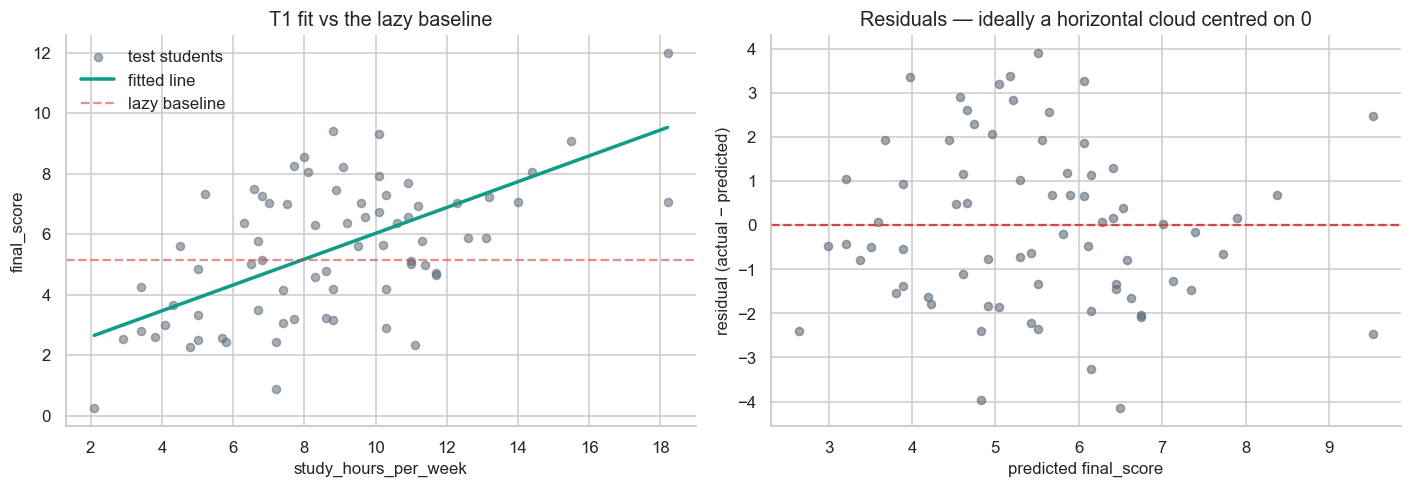

In [9]:
# --- See the fit: predicted vs actual, plus residuals. ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
xs_sorted = np.sort(X1_test.flatten())
ax.scatter(X1_test, y_test, s=28, alpha=0.55, color=COLORS['slate'], label='test students')
ax.plot(xs_sorted, model_t1.predict(xs_sorted.reshape(-1, 1)),
        color=COLORS['teal'], lw=2.3, label='fitted line')
ax.axhline(lazy_prediction, color=COLORS['red'], ls='--', alpha=0.6, label='lazy baseline')
ax.set_xlabel('study_hours_per_week'); ax.set_ylabel('final_score')
ax.set_title('T1 fit vs the lazy baseline')
ax.legend()

ax = axes[1]
residuals = y_test - y_pred_t1
ax.scatter(y_pred_t1, residuals, s=28, alpha=0.6, color=COLORS['slate'])
ax.axhline(0, color=COLORS['red'], ls='--')
ax.set_xlabel('predicted final_score'); ax.set_ylabel('residual (actual − predicted)')
ax.set_title('Residuals — ideally a horizontal cloud centred on 0')

plt.tight_layout(); plt.show()


**What you should see.** A gently rising line that clearly beats the
flat red baseline but is nowhere near perfect. That's expected — one
feature can only explain so much. In T2 we'll add the other five and
watch the error shrink.


## 4. T2 — Multiple linear regression

### The concept

With one feature we had `\hat{y} = w x + b`. With six features we have
*six weights plus one bias*:

$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + w_4 x_4 + w_5 x_5 + w_6 x_6 + b$$

Each weight `w_j` has a concrete interpretation:

> **"If this feature increases by 1 unit and everything else stays the
> same, the prediction changes by `w_j`."**

So the weight on `study_hours_per_week` is "extra grade points per extra
hour of study, holding attendance, prior math, sleep, exercises, and
programming experience fixed."

The training procedure is identical — exactly the same four sklearn
lines. The only thing that changes is the shape of `X`: instead of
`(n, 1)` it's `(n, 6)`.


### Predict before you fit

Take 10 seconds and guess:

- Will R² go **up, down, or stay the same** compared to T1?
- Which of the six features do you expect to have the **largest** weight?
  (Hint: look back at the correlation heatmap.)


### T2 — Train a multiple linear regression

Same task, but now use **all six** features listed in `FEATURE_COLS`. Everything else is identical to T1.

**Required variables after your code runs:** `X6, X6_train, X6_test, y_train, y_test, model_t2, y_pred_t2, mae_t2, mse_t2, r2_t2`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

This is the same five-step recipe as T1. The only thing that changes is **X**: instead of one column it has six. `y` stays the same.

Use the exact same `random_state=42` when splitting so the train and test sets have the same students as T1 — that way R² is a fair comparison.

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

`FEATURE_COLS` was defined in the dataset-building cell and contains all six habit columns in the right order.

- Build X: `df[FEATURE_COLS].values` gives an `(n, 6)` array directly.
- Split, fit, predict, score: *same functions as T1*, different names (`model_t2`, `y_pred_t2`, `mae_t2`, `mse_t2`, `r2_t2`).

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
X6 = df[FEATURE_COLS].values

X6_train, X6_test, y_train, y_test = train_test_split(
    X6, y, test_size=0.2, random_state=42,
)

model_t2 = LinearRegression()
model_t2.fit(X6_train, y_train)

y_pred_t2 = model_t2.predict(X6_test)
mae_t2 = mean_absolute_error(y_test, y_pred_t2)
mse_t2 = mean_squared_error(y_test, y_pred_t2)
r2_t2  = r2_score(y_test, y_pred_t2)
```

</details>


In [10]:
##############################################################
###       T2 -- Multiple linear regression (SOLUTION)      ###
##############################################################
# Required variables:
#   X6, X6_train, X6_test, y_train, y_test,
#   model_t2, y_pred_t2, mae_t2, mse_t2, r2_t2
#
# Same five-step recipe as T1 but X now has six columns. The
# T2_FEATURE_SUBSET KNOB lets variant 2 drop study_hours without
# editing this cell.

# Resolve the subset KNOB into an explicit list of column names so the
# rest of the cell is variant-agnostic.
if T2_FEATURE_SUBSET == 'all':
    t2_cols = list(FEATURE_COLS)
elif T2_FEATURE_SUBSET == 'drop_study_hours':
    t2_cols = [c for c in FEATURE_COLS if c != 'study_hours_per_week']
elif isinstance(T2_FEATURE_SUBSET, (list, tuple)):
    # Caller passed an explicit subset; validate it.
    t2_cols = list(T2_FEATURE_SUBSET)
    unknown = [c for c in t2_cols if c not in FEATURE_COLS]
    if unknown:
        raise ValueError(f'T2_FEATURE_SUBSET contains unknown columns: {unknown}')
else:
    raise ValueError(
        f'T2_FEATURE_SUBSET must be "all", "drop_study_hours", or a list of '
        f'FEATURE_COLS column names. Got: {T2_FEATURE_SUBSET!r}'
    )

print(f'T2 features in use ({len(t2_cols)}): {t2_cols}')

X6 = df[t2_cols].values  # shape (n, k) where k = len(t2_cols)

# Same random_state + test_size as T1 so the train/test split is the
# same students. Reusing y_train / y_test from T1 also works (and would
# be slightly cleaner) but recomputing keeps each task self-contained.
X6_train, X6_test, y_train, y_test = train_test_split(
    X6, y,
    test_size=TEST_SPLIT_RATIO,
    random_state=SPLIT_RANDOM_STATE,
)

model_t2 = LinearRegression()
model_t2.fit(X6_train, y_train)

y_pred_t2 = model_t2.predict(X6_test)
mae_t2 = mean_absolute_error(y_test, y_pred_t2)
mse_t2 = mean_squared_error(y_test, y_pred_t2)
r2_t2 = r2_score(y_test, y_pred_t2)

print(f'T2 metrics:  MAE = {mae_t2:.3f}   MSE = {mse_t2:.3f}   R^2 = {r2_t2:.3f}')

# Stash the column list used for T2 so downstream cells (the coefficient
# bar chart and T4) know which features the model is expecting.
T2_COLS_IN_USE = t2_cols

T2 features in use (6): ['study_hours_per_week', 'attendance_rate_pct', 'prior_math_grade', 'sleep_hours', 'exercises_completed', 'prior_programming_years']
T2 metrics:  MAE = 0.838   MSE = 1.181   R^2 = 0.767


In [11]:
# --- Sanity check for T2. Do NOT edit. ---

print(f'MAE = {mae_t2:.2f}   (expected ~0.85, anything in 0.70–1.05 is fine)')
print(f'MSE = {mse_t2:.2f}   (expected ~1.20, anything in 0.90–1.60 is fine)')
print(f'R^2 = {r2_t2:.3f}  (expected ~0.767, anything in 0.70–0.82 is fine)')
print()

# Adjusted R^2 (L11 §3.7, lecture lines 220–241):
#   R^2_adj = 1 - (n - 1) / (n - p - 1) * (1 - R^2)
# n is the test-set size; p is the number of predictors (intercept
# excluded). This is the right metric for comparing models with
# different p — raw R^2 never decreases when you add a predictor,
# adjusted R^2 *can*.
n_test = len(y_test)
p_t1 = 1                          # T1 used only T1_FEATURE
p_t2 = len(T2_COLS_IN_USE)        # T2 used however many columns the KNOB resolved to
adj_r2_t1 = 1.0 - (n_test - 1) / (n_test - p_t1 - 1) * (1.0 - r2_t1)
adj_r2_t2 = 1.0 - (n_test - 1) / (n_test - p_t2 - 1) * (1.0 - r2_t2)

print(f'T1 (p={p_t1}) raw R^2 = {r2_t1:.3f}   adjusted R^2 = {adj_r2_t1:.3f}')
print(f'T2 (p={p_t2}) raw R^2 = {r2_t2:.3f}   adjusted R^2 = {adj_r2_t2:.3f}')
print(f'Raw R^2 jump:      {r2_t2 - r2_t1:+.3f}')
print(f'Adjusted R^2 jump: {adj_r2_t2 - adj_r2_t1:+.3f}  '
      f'(the honest comparison — more features pay off only if this is positive too)')

# If your numbers are far off, check:
#   * Did you use `FEATURE_COLS` (all six), not a subset?
#   * Did you pass `random_state=42` again?
#   * Are you fitting on X6_train and predicting on X6_test (not X1_*)?


MAE = 0.84   (expected ~0.85, anything in 0.70–1.05 is fine)
MSE = 1.18   (expected ~1.20, anything in 0.90–1.60 is fine)
R^2 = 0.767  (expected ~0.767, anything in 0.70–0.82 is fine)

T1 (p=1) raw R^2 = 0.319   adjusted R^2 = 0.309
T2 (p=6) raw R^2 = 0.767   adjusted R^2 = 0.746
Raw R^2 jump:      +0.449
Adjusted R^2 jump: +0.437  (the honest comparison — more features pay off only if this is positive too)


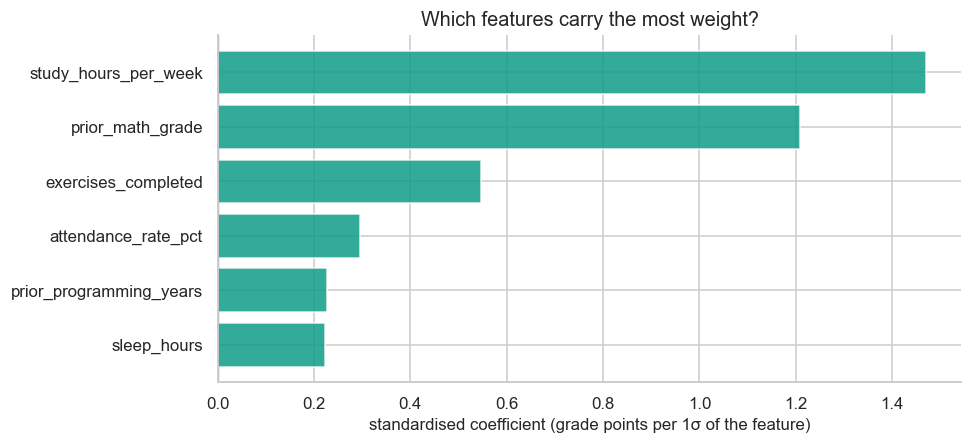

Raw coefficients:


,feature,coefficient,standardised
3,sleep_hours,0.174,0.223
5,prior_programming_years,0.179,0.226
1,attendance_rate_pct,0.026,0.295
4,exercises_completed,0.177,0.546
2,prior_math_grade,0.311,1.208
0,study_hours_per_week,0.452,1.470


In [12]:
# --- Which features did the model rely on? A coefficient bar chart. ---

coef_df = pd.DataFrame({
    'feature': T2_COLS_IN_USE,
    'coefficient': model_t2.coef_,
    'std': X6_train.std(axis=0),
})
# "Standardised" coefficient = coefficient × feature std. This answers
# "how many grade points per one *typical* jump in this feature?", which
# is fair to compare across features on different scales.
coef_df['standardised'] = coef_df['coefficient'] * coef_df['std']
coef_df = coef_df.sort_values('standardised', key=np.abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [COLORS['teal'] if c > 0 else COLORS['red'] for c in coef_df['standardised']]
ax.barh(coef_df['feature'], coef_df['standardised'], color=colors, alpha=0.85)
ax.axvline(0, color=COLORS['slate'])
ax.set_xlabel('standardised coefficient (grade points per 1σ of the feature)')
ax.set_title('Which features carry the most weight?')
plt.tight_layout(); plt.show()

print('Raw coefficients:')
display(coef_df[['feature', 'coefficient', 'standardised']].round(3))


**What to notice.** `study_hours_per_week` and `prior_math_grade` have
the biggest bars — the model learned what the correlation heatmap
hinted at. `sleep_hours` has a small linear coefficient because its
true relationship is quadratic (too little *and* too much sleep hurt),
which a plain line can't express. That's a real limitation of linear
models: they have a fixed shape and pay an accuracy cost on any
non-linear pattern.


## 5. T3 — Overfitting and the train/test gap

### The polynomial-features trick

A linear regression can only draw straight lines — a fundamental
limitation we noted at the end of T2. To let it bend, we can manually
expand a single feature into its squared, cubed, and higher powers,
then fit a linear model on the expanded columns.

`PolynomialFeatures(degree=d, include_bias=False)` is sklearn's helper
for exactly this: pass it a column `x` and it returns the columns
`x, x², ..., xᵈ`. The model is still linear *in its parameters* (it's
multiplying each column by a weight and summing), but as a function of
the original feature it can now curve. More flexibility = more ability
to fit — and, as we're about to see, more ability to **overfit**.

### Overfitting

A model **overfits** when it learns patterns from the training data
that aren't real — noise, flukes, happy accidents — and those patterns
don't transfer to new students. The symptom is always the same:

> **Train R² is high, test R² is much lower.**

The gap is the overfitting signal. A small gap is fine (all models
have some). A big gap is trouble. Today we'll watch three models sit
on exactly the same noisy data and draw different-quality fits.

To make overfitting visible we use a tiny **toy dataset** (only 14
training points, 1 feature) where we control the true curve. You'll
fit three polynomials: degrees 1, 3, and 12. Degree 1 is the straight
line from T1. Degree 12 has enough flexibility to wiggle through
almost any pattern.


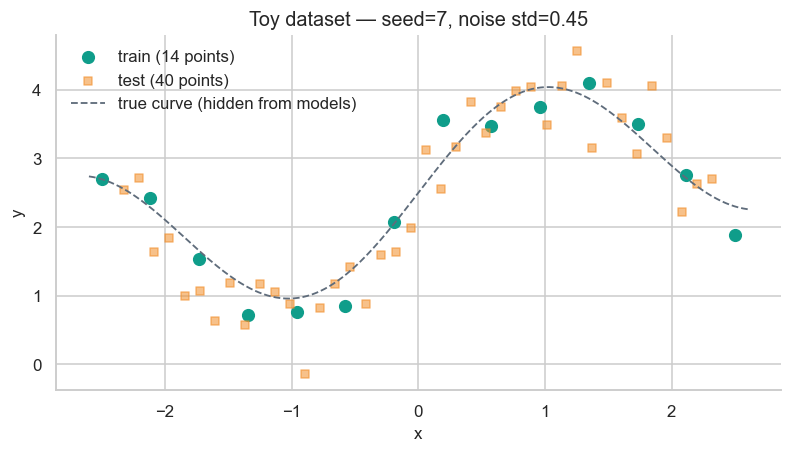

In [13]:
# --- Build a small 1-D toy dataset so overfitting is visually obvious. ---

# The TOY_RANDOM_SEED / TOY_N_TRAIN / TOY_NOISE_STD KNOBs are declared
# in cell 8 alongside the polynomial-sweep knobs. Variant 1 may keep
# them at their defaults; advanced variants can perturb them to study
# the seed/size/noise sensitivity of the overfitting collapse.
toy_rng = np.random.default_rng(TOY_RANDOM_SEED)
true_curve = lambda x: 2.5 + 1.2 * np.sin(1.7 * x) + 0.35 * x

# Training points: TOY_N_TRAIN evenly spaced on [-2.5, 2.5], noise std =
# TOY_NOISE_STD. Few training points + a flexible model is the recipe
# that makes overfitting dramatic.
x_train_toy = np.linspace(-2.5, 2.5, TOY_N_TRAIN)
y_train_toy = true_curve(x_train_toy) + toy_rng.normal(0, TOY_NOISE_STD, TOY_N_TRAIN)

# 40 interior test points, offset so they fall between the training points.
# The test set size is kept fixed (40) regardless of TOY_N_TRAIN so the
# test-R^2 estimate variance stays comparable across variants.
offset = (5.0 / max(TOY_N_TRAIN, 2)) * 0.5
x_test_toy = np.linspace(-2.5 + offset, 2.5 - offset, 40)
y_test_toy = true_curve(x_test_toy) + toy_rng.normal(0, TOY_NOISE_STD, 40)

# Dense grid for drawing fitted curves smoothly. Slightly wider than the
# data range so the polynomial wings are visible at the edges.
x_grid = np.linspace(-2.6, 2.6, 300)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.scatter(x_train_toy, y_train_toy, s=58, color=COLORS['teal'],
           label=f'train ({TOY_N_TRAIN} points)')
ax.scatter(x_test_toy, y_test_toy, s=26, marker='s', alpha=0.55,
           color=COLORS['orange'], label='test (40 points)')
ax.plot(x_grid, true_curve(x_grid), color=COLORS['slate'], ls='--', lw=1.2,
        label='true curve (hidden from models)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Toy dataset — seed={TOY_RANDOM_SEED}, noise std={TOY_NOISE_STD}')
ax.legend()
plt.show()


### T3 — Measure underfit, good-fit, and overfit

For each polynomial degree in `[1, 3, 12]`, fit the model to the toy training data and compute **train R²** and **test R²**. The train-test gap is the overfitting alarm bell.

**Required variables after your code runs:** `toy_records, toy_fits`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

This is a loop over three degrees. Each iteration does the same thing:

1. Expand the 1-D input into polynomial features of the current degree.
2. Fit a `LinearRegression` on the expanded training data.
3. Evaluate R² on train *and* on test separately.
4. Save the results so you can plot them afterwards.

Before the loop, create two empty containers: a list `toy_records` (will hold `(degree, train_r2, test_r2)` triples) and a dict `toy_fits` (will hold the fitted model + poly object per degree, so the verify cell can redraw the curves).

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

- `poly_d = PolynomialFeatures(degree=d, include_bias=False)`
- Sklearn expects **2-D** inputs. Reshape the 1-D toy arrays:
  `x_train_toy.reshape(-1, 1)` and `x_test_toy.reshape(-1, 1)`.
- Use `poly_d.fit_transform(...)` on train (learns + transforms in one call), then `poly_d.transform(...)` on test (reuses the same learned expansion).
- `r2_score(y_true, y_pred)` — call it twice per degree, once with the train set and once with the test set.
- Store the fit: `toy_fits[d] = (poly_d, model)`.

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
toy_records = []
toy_fits = {}

for d in [1, 3, 12]:
    poly_d = PolynomialFeatures(degree=d, include_bias=False)
    Xtr = poly_d.fit_transform(x_train_toy.reshape(-1, 1))
    Xte = poly_d.transform(x_test_toy.reshape(-1, 1))

    m = LinearRegression().fit(Xtr, y_train_toy)
    train_r2 = r2_score(y_train_toy, m.predict(Xtr))
    test_r2  = r2_score(y_test_toy,  m.predict(Xte))

    toy_records.append((d, train_r2, test_r2))
    toy_fits[d] = (poly_d, m)
```

</details>


In [14]:
##############################################################
###            T3 -- Overfitting sweep (SOLUTION)          ###
##############################################################
# Required variables:
#   toy_records  -- list of (degree, train_r2, test_r2) tuples for the
#                   default sweep (POLY_DEGREES_SWEEP)
#   toy_fits     -- dict mapping degree to (poly_object, fitted_model)
#                   for the default sweep
#   toy_records2 -- same shape as toy_records but for POLY_DEGREES_SWEEP_2
#   toy_fits2    -- same shape as toy_fits but for POLY_DEGREES_SWEEP_2
#
# Loop over POLY_DEGREES_SWEEP, then over POLY_DEGREES_SWEEP_2. For
# each degree we: expand the 1-D toy x into polynomial columns x, x^2,
# ... x^d; fit a LinearRegression on those columns; score R^2 on the
# same train split and on the held-out test split. The gap
# (train_r2 - test_r2) is the overfitting signal -- nearly zero for
# the right degree, large for the over-flexible model.

def _run_poly_sweep(degrees):
    """Run one full polynomial-degree sweep on the toy dataset.

    Returns (records, fits) where records is a list of
    (degree, train_r2, test_r2) tuples and fits is a dict
    mapping degree to (PolynomialFeatures, fitted LinearRegression).
    """
    records = []
    fits = {}
    for d in degrees:
        # PolynomialFeatures(degree=d) expands one column x into x, x^2, ..., x^d.
        # include_bias=False because LinearRegression already learns its
        # own intercept; including a bias column would be redundant.
        poly_d = PolynomialFeatures(degree=d, include_bias=False)

        # fit_transform learns the expansion (which power columns to
        # emit) AND applies it; transform applies the SAME expansion
        # to test data.
        Xtr = poly_d.fit_transform(x_train_toy.reshape(-1, 1))
        Xte = poly_d.transform(x_test_toy.reshape(-1, 1))

        m = LinearRegression().fit(Xtr, y_train_toy)

        # Two R^2 scores: train (how well it fits points it saw) and test
        # (how well it generalises). The gap is the diagnostic.
        train_r2 = r2_score(y_train_toy, m.predict(Xtr))
        test_r2 = r2_score(y_test_toy, m.predict(Xte))

        records.append((d, train_r2, test_r2))
        fits[d] = (poly_d, m)
    return records, fits


toy_records, toy_fits = _run_poly_sweep(POLY_DEGREES_SWEEP)

# Second sweep, possibly empty if the variant disabled it.
toy_records2, toy_fits2 = _run_poly_sweep(POLY_DEGREES_SWEEP_2)

# Quick text summary so the printout is intelligible even if the
# verify cell's plotting fails. Variant 1 asks for "six rows" — we
# print both sweeps in one table.
print('Polynomial degree sweep #1 (POLY_DEGREES_SWEEP):')
for d, tr, te in toy_records:
    print(f'  degree {d:>2d}:  train R^2 = {tr:6.3f}   test R^2 = {te:6.3f}'
          f'   gap = {tr - te:+6.3f}')
if toy_records2:
    print('Polynomial degree sweep #2 (POLY_DEGREES_SWEEP_2):')
    for d, tr, te in toy_records2:
        print(f'  degree {d:>2d}:  train R^2 = {tr:6.3f}   test R^2 = {te:6.3f}'
              f'   gap = {tr - te:+6.3f}')


Polynomial degree sweep #1 (POLY_DEGREES_SWEEP):
  degree  1:  train R^2 =  0.215   test R^2 =  0.368   gap = -0.153
  degree  3:  train R^2 =  0.882   test R^2 =  0.867   gap = +0.015
  degree 12:  train R^2 =  0.999   test R^2 =  0.486   gap = +0.513
Polynomial degree sweep #2 (POLY_DEGREES_SWEEP_2):
  degree  2:  train R^2 =  0.215   test R^2 =  0.367   gap = -0.151
  degree  6:  train R^2 =  0.967   test R^2 =  0.881   gap = +0.086
  degree 18:  train R^2 =  1.000   test R^2 = -6802.245   gap = +6803.245


   sweep    degree   train R^2    test R^2       gap
      #1         1       0.215       0.368    -0.153
      #1         3       0.882       0.867    +0.015
      #1        12       0.999       0.486    +0.513
      #2         2       0.215       0.367    -0.151
      #2         6       0.967       0.881    +0.086
      #2        18       1.000   -6802.245  +6803.245

Expected patterns (default knobs):
  Sweep #1 (1, 3, 12): degree 1 R^2 ~ 0.2–0.4 (underfit), degree 3 ~ 0.85–0.90
                       (good fit), degree 12 train near 1.0 / test much lower (overfit).
  Sweep #2 (2, 6, 18): same underfit -> goodfit -> overfit pattern at higher scale.


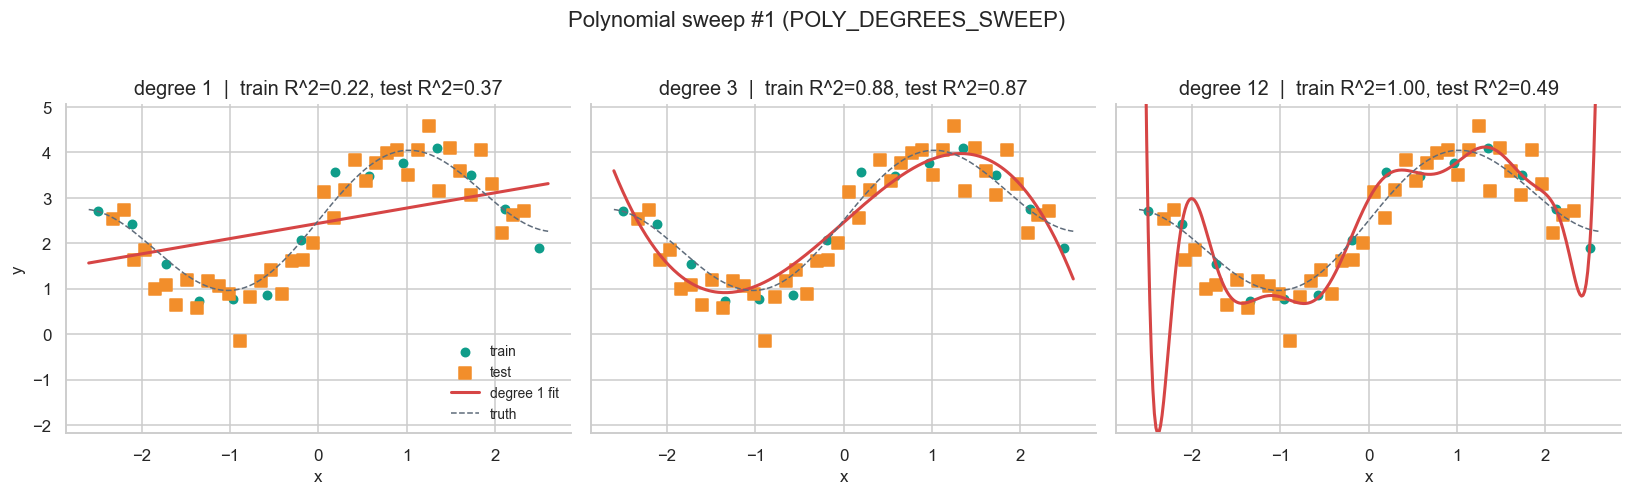

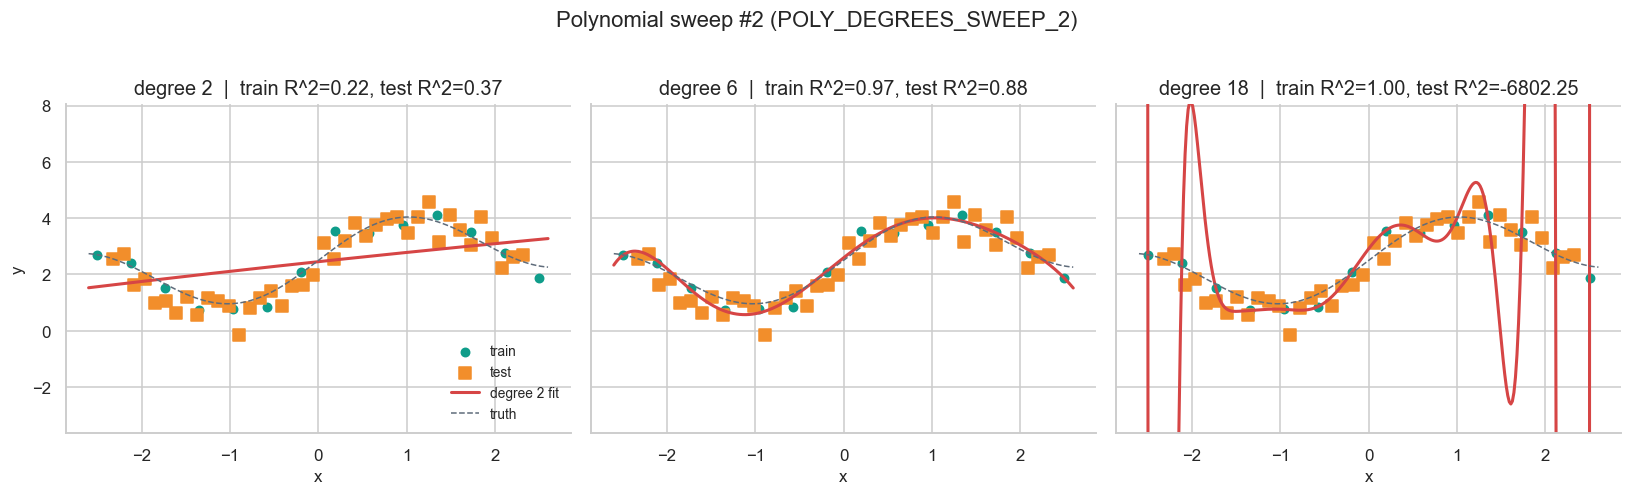

In [15]:
# --- Sanity check for T3 + side-by-side picture(s) of all fits. ---

print(f"{'sweep':>8s}  {'degree':>8s}  {'train R^2':>10s}  {'test R^2':>10s}  {'gap':>8s}")
for d, tr, te in toy_records:
    print(f'{"#1":>8s}  {d:>8d}  {tr:>10.3f}  {te:>10.3f}  {tr - te:>+8.3f}')
for d, tr, te in toy_records2:
    print(f'{"#2":>8s}  {d:>8d}  {tr:>10.3f}  {te:>10.3f}  {tr - te:>+8.3f}')

print()
print('Expected patterns (default knobs):')
print('  Sweep #1 (1, 3, 12): degree 1 R^2 ~ 0.2–0.4 (underfit), degree 3 ~ 0.85–0.90')
print('                       (good fit), degree 12 train near 1.0 / test much lower (overfit).')
print('  Sweep #2 (2, 6, 18): same underfit -> goodfit -> overfit pattern at higher scale.')


def _plot_sweep(records, fits, sweep_label):
    """Draw one 1 x N panel for a single sweep, N = len(records).

    Adapts to any sweep length — no hard-coded 3.
    """
    if not records:
        return
    n_panels = len(records)
    fig, axes = plt.subplots(1, n_panels,
                             figsize=(5.0 * n_panels, 4.4),
                             sharey=True, squeeze=False)
    axes = axes[0]
    x_plot_grid = np.linspace(-2.6, 2.6, 300)
    for ax, (d, tr, te) in zip(axes, records):
        poly_d, m = fits[d]
        y_fit = m.predict(poly_d.transform(x_plot_grid.reshape(-1, 1)))
        ax.scatter(x_train_toy, y_train_toy, s=30, color=COLORS['teal'], label='train')
        ax.scatter(x_test_toy, y_test_toy, s=55, marker='s',
                   color=COLORS['orange'], label='test')
        ax.plot(x_plot_grid, y_fit, color=COLORS['red'], lw=2,
                label=f'degree {d} fit')
        ax.plot(x_plot_grid, true_curve(x_plot_grid), color=COLORS['slate'],
                ls='--', lw=1, label='truth')
        ax.set_title(f'degree {d}  |  train R^2={tr:.2f}, test R^2={te:.2f}')
        ax.set_xlabel('x')
        if ax is axes[0]:
            ax.set_ylabel('y')
        # ylim chosen from the **data** with a small buffer, then loosened
        # slightly toward the fit if it stays civil. A divergent very-high-
        # degree fit (e.g. degree 18 on 14 train points) will blow up far
        # outside the data range — clamping to a sensible window keeps the
        # picture readable while the printed table still tells the true
        # numerical story (test R^2 in the thousands of negative).
        y_data_lo = float(min(y_train_toy.min(), y_test_toy.min())) - 0.5
        y_data_hi = float(max(y_train_toy.max(), y_test_toy.max())) + 0.5
        # Compute the fit's range only on x within the data envelope (not
        # the wide x_plot_grid edges where high-degree wings explode).
        in_envelope = (x_plot_grid >= -2.5) & (x_plot_grid <= 2.5)
        if in_envelope.any():
            y_fit_lo = float(y_fit[in_envelope].min())
            y_fit_hi = float(y_fit[in_envelope].max())
            y_lo = min(y_data_lo, max(y_fit_lo, y_data_lo - 3.0))
            y_hi = max(y_data_hi, min(y_fit_hi, y_data_hi + 3.0))
        else:
            y_lo, y_hi = y_data_lo, y_data_hi
        ax.set_ylim(y_lo, y_hi)
    axes[0].legend(loc='lower right', fontsize=9)
    fig.suptitle(f'Polynomial sweep {sweep_label}', y=1.02)
    plt.tight_layout(); plt.show()


_plot_sweep(toy_records, toy_fits, '#1 (POLY_DEGREES_SWEEP)')
_plot_sweep(toy_records2, toy_fits2, '#2 (POLY_DEGREES_SWEEP_2)')


**What to notice.** Degree 12 is a warning sign: the curve wiggles
through almost every training point but misses the test points badly.
The test R² is the honest scoreboard — degree 3 wins. A model is only
as good as its test performance.


## 6. T4 — Predict your own grade

Time for the payoff. Fill in your own study habits below. The model
from T2 (the 6-feature linear regression) will predict your
`final_score`. We'll then snap it to the Danish scale and show which
habits pushed your prediction up vs down compared to the class average.

*This is not a real grade predictor. The dataset is synthetic and the
model is linear — it can't see the non-linear truths of exam day. Treat
the output as a conversation starter, not a fortune.*


### T4 — what to do

1. In the `my_profile` dict below, replace each value with something
   realistic for you. Any numbers inside the feature ranges work:
   - `study_hours_per_week`: 0–20
   - `attendance_rate_pct`: 0–100
   - `prior_math_grade`: one of `-3, 0, 2, 4, 7, 10, 12`
   - `sleep_hours`: 3–10
   - `exercises_completed`: 0–10
   - `prior_programming_years`: 0–6
2. Leave the rest of the cell alone — it converts your dict to the
   array shape the model expects and stores the prediction in
   `my_score`.


In [16]:
##############################################################
###         T4 -- Fill in YOUR study habits (SOLUTION)     ###
##############################################################
# This is the only TODO cell where the "solution" is to commit a
# meaningful default. The KNOB block below documents allowed ranges
# for each field so a variant-3 examiner can override every value
# without reading the dataset-builder.

# KNOB: my_profile (default=below, range=per-field below)
#   What it does: the inputs for the "predict your own grade" demo.
#     Every field is one of the six features the T2 model was trained
#     on (see FEATURE_COLS).
#   Effect: model_t2 makes a linear prediction for this single row.
#     Each field's marginal contribution to the predicted score is
#     `coefficient * (your_value - class_average)`, plotted by the
#     verify cell below.
#   Allowed ranges (clipped at the dataset's hard bounds):
#     - study_hours_per_week     :  0.5 .. 20.0 hours/week
#     - attendance_rate_pct      : 40.0 .. 100.0 percent
#     - prior_math_grade         : one of {-3, 0, 2, 4, 7, 10, 12}
#     - sleep_hours              :  3.0 .. 10.0 hours
#     - exercises_completed      :  0   .. 10   (integer)
#     - prior_programming_years  :  0.0 .. 6.0
#   Exam variants: variant 3 overrides every entry with a new student's
#     numbers (see study/_exam/MLLab2-Regression/variants.md).
my_profile = {
    'study_hours_per_week':    12.0,   # your honest weekly study hours (0-20)
    'attendance_rate_pct':     90.0,   # your attendance %  (0-100)
    'prior_math_grade':        10,     # your previous math grade (-3, 0, 2, 4, 7, 10, 12)
    'sleep_hours':             7.5,    # your average sleep  (3-10)
    'exercises_completed':     9,      # weekly exercises you finish (0-10)
    'prior_programming_years': 2.0,    # years of prior programming  (0-6)
}

# Convert my_profile dict into a (1, k) array in the column order the
# T2 model expects. Uses T2_COLS_IN_USE so that variant 2 (dropped
# feature) and variant 3 (new student row) compose: if T2 was trained
# without study_hours, my_profile loses that field automatically.
my_x = np.array([[my_profile[c] for c in T2_COLS_IN_USE]])
my_score = float(model_t2.predict(my_x)[0])
my_grade = int(snap_to_danish(np.array([my_score]))[0])

print(f'my_profile (k={len(T2_COLS_IN_USE)} features used by T2): {my_profile}')
print(f'Predicted final_score: {my_score:.2f}   ->  Danish grade: {my_grade}')

my_profile (k=6 features used by T2): {'study_hours_per_week': 12.0, 'attendance_rate_pct': 90.0, 'prior_math_grade': 10, 'sleep_hours': 7.5, 'exercises_completed': 9, 'prior_programming_years': 2.0}
Predicted final_score: 9.70   ->  Danish grade: 10


Predicted final_score :   9.70   (continuous, before snapping)
Predicted Danish grade:     10   (nearest of -3, 00, 02, 4, 7, 10, 12)


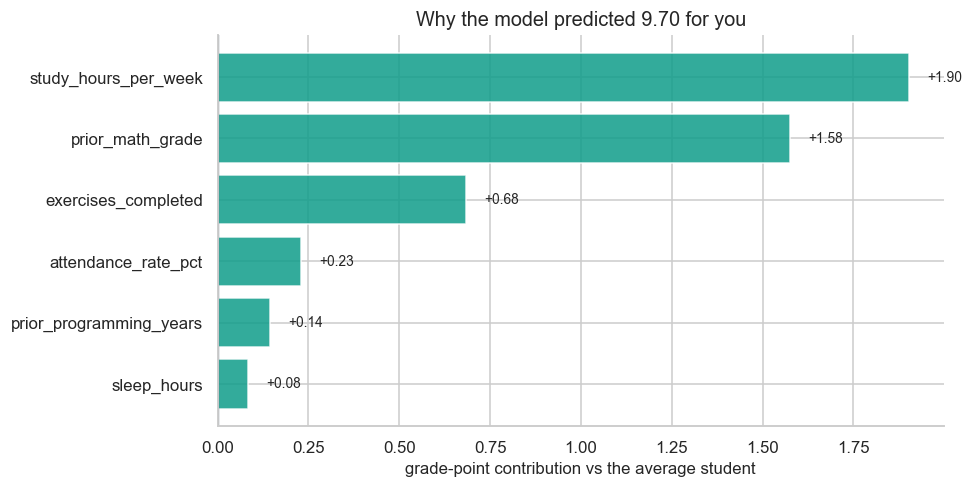


Reading the chart:
  • Teal bars (positive) — habits that pushed your prediction up.
  • Red bars (negative)  — habits that pulled your prediction down.
  • The sum of all bars + the class average ≈ your predicted score.


In [17]:
# --- The reveal + feature-contribution breakdown. ---

grade_label = '00' if my_grade == 0 else ('02' if my_grade == 2 else str(my_grade))
print('=' * 60)
print(f'Predicted final_score : {my_score:6.2f}   (continuous, before snapping)')
print(f'Predicted Danish grade: {grade_label:>6s}   (nearest of -3, 00, 02, 4, 7, 10, 12)')
print('=' * 60)

# Contribution = coefficient × (your_value − class_average)
# i.e. how many grade points each habit adds or subtracts vs the average student.
avg_profile = X6_train.mean(axis=0)  # mean of the columns T2 was trained on
contribs = model_t2.coef_ * (my_x.flatten() - avg_profile)

order = np.argsort(contribs)
sorted_features = [T2_COLS_IN_USE[i] for i in order]
sorted_contribs = contribs[order]
colors = [COLORS['teal'] if c >= 0 else COLORS['red'] for c in sorted_contribs]

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(sorted_features, sorted_contribs, color=colors, alpha=0.85)
ax.axvline(0, color=COLORS['slate'])
ax.set_xlabel('grade-point contribution vs the average student')
ax.set_title(f'Why the model predicted {my_score:.2f} for you')
for i, c in enumerate(sorted_contribs):
    ax.text(c + (0.05 if c >= 0 else -0.05), i, f'{c:+.2f}',
            va='center', ha='left' if c >= 0 else 'right', fontsize=9)
plt.tight_layout(); plt.show()

print()
print('Reading the chart:')
print('  • Teal bars (positive) — habits that pushed your prediction up.')
print('  • Red bars (negative)  — habits that pulled your prediction down.')
print('  • The sum of all bars + the class average ≈ your predicted score.')


**Experiment.** Change one number in `my_profile` and re-run this cell
and the one above. For example, set `study_hours_per_week` to `2.0`.
Watch how the teal bar for study shrinks and becomes red, and your
predicted score drops. That's the power of a linear model: the effect
of each feature is transparent and additive.


## 7. T5 (bonus) — Gradient descent from scratch

Everything above used sklearn's `.fit()` as a black box. Under the
hood, `LinearRegression` solves the best `w, b` with a closed-form
matrix equation. But for big models (neural networks, for example),
we can't solve it in closed form — we have to search for the answer
iteratively with **gradient descent**.

The idea: define a loss function `L(w, b) = MSE(model, data)` over the
two knobs, then repeatedly nudge the knobs in the direction that makes
the loss go down. The "direction that makes loss go down" is the
**negative gradient**.

For one-feature linear regression with MSE loss, the gradients are:

$$\frac{\partial L}{\partial w} = \frac{2}{n} \sum_i (w x_i + b - y_i) \cdot x_i$$

$$\frac{\partial L}{\partial b} = \frac{2}{n} \sum_i (w x_i + b - y_i)$$

The update rule is `w ← w − lr · dw`, `b ← b − lr · db`, where `lr` is
the *learning rate* — a small positive number that controls step size.

You'll implement 100 epochs of this on the T1 single-feature problem
(`study_hours_per_week → final_score`) and show that the loss curve
goes down and the final `(w, b)` match sklearn's answer.

For numerical stability we normalise the input feature first (subtract
mean, divide by std). That keeps the gradients on the same scale as
the loss.


In [18]:
# --- Prep for gradient descent. Run this cell. ---

x_gd_raw = df['study_hours_per_week'].values.astype(float)
y_gd     = df['final_score'].values.astype(float)

# Normalise x so the gradients are well-scaled.
x_mean = x_gd_raw.mean(); x_std = x_gd_raw.std()
x_gd = (x_gd_raw - x_mean) / x_std

n = len(x_gd)
w = 0.0
b = 0.0
# KNOB: GD_LEARNING_RATE (default=0.05, range=(1e-4 .. ~0.2))
#   What it does: step size of the manual gradient-descent loop in T5.
#   Effect: too small -> the loss curve barely moves in 100 epochs and
#     w/b don't reach sklearn's answer (variant-4 sub-question). Too
#     large -> the updates overshoot and oscillate / diverge; loss
#     curve climbs instead of dropping. The sweet spot for this 1-D
#     standardised problem is ~0.01-0.1.
#   Exam variants: variant 4 (bonus) flips this between 0.005 and 0.5
#     to show the cautious-vs-unstable failure modes.
GD_LEARNING_RATE = 0.05
lr = GD_LEARNING_RATE
# KNOB: GD_N_EPOCHS (default=100, range=10 .. 5000)
#   What it does: number of full-batch gradient-descent updates in T5.
#   Effect: more epochs -> closer to sklearn's closed-form answer,
#     diminishing returns once the loss curve has plateaued. The
#     default 100 is comfortably enough for lr=0.05 to converge to
#     |delta w|, |delta b| < 0.05 of sklearn.
#   Exam variants: pair this knob with GD_LEARNING_RATE -- a small lr
#     needs more epochs to reach the same accuracy.
GD_N_EPOCHS = 100
n_epochs = GD_N_EPOCHS
loss_history = []

# For comparison, compute sklearn's answer on the same (normalised) inputs.
sk = LinearRegression().fit(x_gd.reshape(-1, 1), y_gd)
sk_w, sk_b = float(sk.coef_[0]), float(sk.intercept_)
print(f'sklearn target answer (on normalised x): w = {sk_w:.4f}, b = {sk_b:.4f}')


sklearn target answer (on normalised x): w = 1.3758, b = 5.1547


### T5 (bonus) — Gradient descent by hand

Run the pre-filled setup cell above (it prepares `x_gd`, `y_gd`, `w`, `b`, `lr`, `n`, `n_epochs`, `loss_history`). Then write the body of the `for epoch in range(n_epochs):` loop so after 100 iterations your `(w, b)` match sklearn's closed-form answer.

**Required variables after your code runs:** `w, b, loss_history`

If you're new to ML code, try first on your own, then open the hints one at
a time.

<details><summary>Hint 1 — the approach (no code yet)</summary>

Inside the loop, each iteration has five tiny steps in this order:

1. **Predict** with the current knobs: for every student, `y_hat = w * x_gd + b` (this is a vector operation).
2. **Error** of each prediction: `error = y_hat - y_gd`.
3. **Gradients** — how much the loss would change if we nudged `w` or `b`. Formulas are written out in hint 2.
4. **Update** the knobs against the gradient (minus, because we want to *decrease* the loss).
5. **Record** the current MSE in `loss_history` so we can plot convergence.

</details>

<details><summary>Hint 2 — the sklearn calls</summary>

The MSE gradient formulas for one-feature linear regression:

- `dw = (2.0 / n) * (error * x_gd).sum()`
- `db = (2.0 / n) * error.sum()`

The update rule for each knob uses the learning rate `lr`:

- `w = w - lr * dw`
- `b = b - lr * db`

Record the loss (mean of `error ** 2`) at the end of each iteration:

`loss_history.append(float((error ** 2).mean()))`

</details>

<details><summary>Hint 3 — a near-solution skeleton (understand every line)</summary>

```python
for epoch in range(n_epochs):
    y_hat = w * x_gd + b
    error = y_hat - y_gd

    dw = (2.0 / n) * (error * x_gd).sum()
    db = (2.0 / n) * error.sum()

    w = w - lr * dw
    b = b - lr * db

    loss_history.append(float((error ** 2).mean()))
```

</details>


In [19]:
##############################################################
###       T5 (bonus) -- Gradient descent by hand (SOLUTION) ###
##############################################################
# Required variables:
#   w, b          -- updated parameters after n_epochs updates
#   loss_history  -- list of n_epochs MSE values, one per epoch
#
# Five-step update rule per epoch (vector ops over all n students):
#   1. y_hat = w * x_gd + b
#   2. error = y_hat - y_gd
#   3. dw = (2/n) * sum(error * x_gd)      # partial dL/dw of MSE
#      db = (2/n) * sum(error)             # partial dL/db
#   4. w <- w - lr * dw    (gradient *descent*: step against gradient)
#      b <- b - lr * db
#   5. record MSE = mean(error**2) for plotting convergence

for epoch in range(n_epochs):
    y_hat = w * x_gd + b
    error = y_hat - y_gd

    # Gradients of MSE = mean((y_hat - y)^2) with respect to w and b.
    # The 2/n constant matches the analytic derivative; absorbing the 2
    # into lr would work too (cosmetic).
    dw = (2.0 / n) * (error * x_gd).sum()
    db = (2.0 / n) * error.sum()

    # Update step: move opposite to the gradient by lr.
    w = w - lr * dw
    b = b - lr * db

    # Loss for plotting -- use the pre-update error so the first entry
    # is the loss BEFORE this step's update (typical convention; the
    # verify cell's expected loss curve assumes this).
    loss_history.append(float((error ** 2).mean()))

print(f'After {n_epochs} epochs:  w = {w:.4f}, b = {b:.4f}')
print(f'Loss history: first = {loss_history[0]:.4f}, last = {loss_history[-1]:.4f}')

After 100 epochs:  w = 1.3757, b = 5.1546
Loss history: first = 31.8032, last = 3.3393


Gradient descent after 100 epochs:  w = 1.3757, b = 5.1546
Sklearn closed-form answer:           w = 1.3758, b = 5.1547
|delta w| = 0.0000  |delta b| = 0.0001  (expected < 0.05 each)


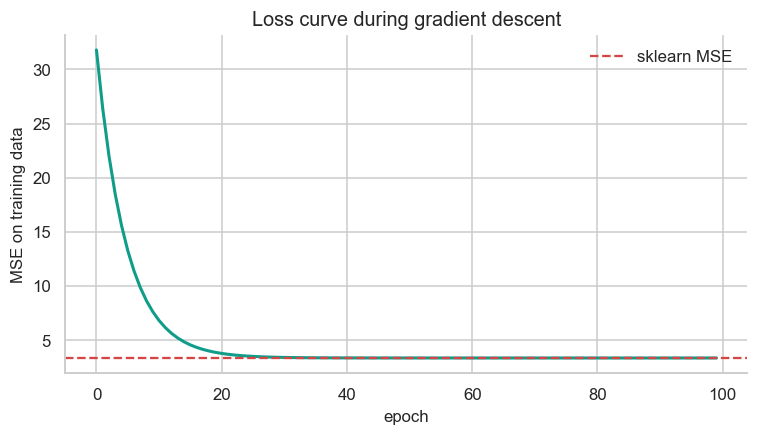

In [20]:
# --- Sanity check + loss curve. ---

print(f'Gradient descent after {n_epochs} epochs:  w = {w:.4f}, b = {b:.4f}')
print(f'Sklearn closed-form answer:           w = {sk_w:.4f}, b = {sk_b:.4f}')
print(f'|delta w| = {abs(w - sk_w):.4f}  |delta b| = {abs(b - sk_b):.4f}  (expected < 0.05 each)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color=COLORS['teal'], lw=2)
ax.axhline(((sk.predict(x_gd.reshape(-1, 1)) - y_gd) ** 2).mean(),
           color=COLORS['red'], ls='--', label='sklearn MSE')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE on training data')
ax.set_title('Loss curve during gradient descent')
ax.legend()
plt.show()


**What to notice.** Two lines of update rule + 100 epochs ≈ the same
answer sklearn got by solving a matrix equation. The loss curve drops
quickly at first and then flattens out — the classic shape of gradient
descent. Congratulations: you've just implemented the core loop that
trains every neural network in the world, on 1-D data.


## Summary — what you just did

1. **Built a regression model from scratch** — chose features, split
   the data, fit a line, measured error with MAE, MSE, R².
2. **Added more features** and watched accuracy climb dramatically.
3. **Witnessed overfitting** by cranking polynomial degree to 12 on a
   tiny toy dataset — train R² near 1.0, test R² collapsed.
4. **Predicted your own grade** and saw exactly which habits moved the
   needle.
5. (Bonus) **Implemented gradient descent by hand** and recovered the
   same parameters sklearn computed in closed form.

Everything you've seen here — residuals, the train/test split,
coefficients, overfitting, gradient descent — generalises directly to
deeper models. Linear regression is not a toy; it's the atom every
more complex predictor is built from.

**Homework waits below.** Take what you've built and apply it to real
California housing data.


## Homework — Try it on California housing prices

You've seen the regression workflow on synthetic student grades. For
homework, **repeat the same flow on a real, noisy dataset**: California
housing prices. This is a larger, dirtier dataset than the students —
handling it yourself is the real practice.

### Getting the data

No download needed; sklearn ships with it:

```python
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df_h = housing.frame
print(df_h.shape)
print(df_h.columns.tolist())
df_h.head()
```

**Target.** `MedHouseVal` — median house value in a district, measured
in units of `$100,000`. Target values are capped at `5.0`, which
creates a pile-up at the top of the distribution — be ready for that.

**Features (8).** `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`,
`Population`, `AveOccup`, `Latitude`, `Longitude`.

### What to do

Reproduce **T1**, **T2**, and **T3** from the lab on this dataset.

1. **T1 on housing — simple linear regression.** Fit on `MedInc` alone
   to predict `MedHouseVal`. Report MAE, MSE, R². Expected R² around
   **0.45**. Which direction does the slope go? Does that make sense?
2. **T2 on housing — multiple linear regression.** Fit on all eight
   features. Expected R² around **0.60**. Make the coefficient bar
   chart. Which feature has the largest standardised coefficient?
   Which has a *negative* coefficient, and why might that be?
3. **T3 on housing — an overfitting demo.** Pick any single feature
   (for example `MedInc` or `AveOccup`), take a small random sample
   (say 20 training points), and sweep polynomial degrees `[1, 3, 12]`
   exactly like we did with the toy dataset in T3. Where does
   overfitting become obvious?
